# Lab 3: Transformer for Classification and Seq2Seq

**Part 2 — From RNNs to Transformers**

---

## Objectives

In this lab we move from recurrent architectures (Lab 2) to **Transformer-based** models. We will:

1. **Fine-tune BERT** for sentiment analysis on the IMDB dataset and compare it to the LSTM baseline from Lab 2.
2. **Use T5** for sequence-to-sequence tasks (summarization and translation).
3. **Compare Transformer vs. LSTM** performance on the same classification task.
4. **Visualize attention weights** across layers and heads to understand what the model learns.
5. **Experiment with different tokenizers** (Word-level, BPE, WordPiece, SentencePiece) and measure their impact on vocabulary size, sequence length, and downstream performance.

---

### Key Formulas from the Course (Part 2 Slides)

**Scaled Dot-Product Attention:**

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

where $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are linear projections of the input, and $d_k$ is the dimension of each key vector. The $\sqrt{d_k}$ scaling prevents the dot products from growing too large in magnitude.

**Multi-Head Attention:**

$$\text{MultiHead}(Q, K, V) = \text{Concat}(h_1, \ldots, h_H)\, W^O$$
$$\text{where } h_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

Each head learns a different "perspective" — syntactic relations, coreference, semantic similarity, etc.

**Position-wise Feed-Forward Network (FFN):**

$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

Applied independently to each position. Typically expands from $d_{\text{model}}$ to $d_{ff} = 4 \cdot d_{\text{model}}$ and contracts back.

**Residual Connection + Layer Normalization:**

$$\text{output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

**Sinusoidal Positional Encoding:**

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

## 0. Environment Setup

In [1]:
# Install dependencies (uncomment if needed, e.g. on Google Colab)
# !pip install transformers datasets tokenizers torch matplotlib seaborn scikit-learn sentencepiece

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

import transformers
print(f"Transformers version: {transformers.__version__}")

Using device: cpu
PyTorch version: 2.10.0
Transformers version: 4.49.0


---

# Part 1: Fine-Tuning BERT for Sentiment Analysis

BERT (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) is an **encoder-only** Transformer pre-trained with two objectives:

1. **Masked Language Modeling (MLM):** Randomly mask 15% of input tokens and predict them using bidirectional context.
2. **Next Sentence Prediction (NSP):** Classify whether sentence B follows sentence A.

Unlike GPT (decoder-only, left-to-right), BERT sees the **full context** in both directions — making it particularly strong for classification, NER, and question answering.

### BERT Architecture Recap

- **Input:** `[CLS] token_1 token_2 ... token_n [SEP]`
- The `[CLS]` token's final hidden state is used as the aggregate sequence representation for classification.
- BERT-base: 12 layers, 12 heads, $d_{\text{model}} = 768$, ~110M parameters.

### Fine-Tuning Strategy

We add a simple linear classification head on top of the `[CLS]` representation:

$$\hat{y} = \text{softmax}(W \cdot h_{[\text{CLS}]} + b)$$

All parameters (pre-trained BERT + classification head) are updated with a **small learning rate** (typically $2 \times 10^{-5}$) to avoid catastrophic forgetting.

## 1.1 Load the IMDB Dataset

In [3]:
from datasets import load_dataset

# Load IMDB — same dataset as Lab 2 for fair comparison
dataset = load_dataset('imdb')
print(dataset)
print(f"\nTrain examples: {len(dataset['train'])}")
print(f"Test examples:  {len(dataset['test'])}")
print(f"\nSample review (first 200 chars): {dataset['train'][0]['text'][:200]}...")
print(f"Label: {dataset['train'][0]['label']} (0=negative, 1=positive)")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train examples: 25000
Test examples:  25000

Sample review (first 200 chars): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label: 0 (0=negative, 1=positive)


## 1.2 Tokenization with BERT's WordPiece Tokenizer

BERT uses a **WordPiece** tokenizer:
- Splits rare words into known subword units (e.g., `"unbelievable"` → `["un", "##believ", "##able"]`)
- The `##` prefix indicates a continuation of the previous token.
- Vocabulary size: ~30,522 tokens for `bert-base-uncased`.

The tokenizer also handles:
- Adding `[CLS]` and `[SEP]` special tokens
- Padding and truncation to a fixed length
- Creating `attention_mask` (1 for real tokens, 0 for padding)

In [4]:
from transformers import AutoTokenizer

MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Demonstrate tokenization
example = "This movie was absolutely unbelievable!"
tokens = tokenizer.tokenize(example)
token_ids = tokenizer.encode(example)

print(f"Original:   {example}")
print(f"Tokens:     {tokens}")
print(f"Token IDs:  {token_ids}")
print(f"Decoded:    {tokenizer.decode(token_ids)}")
print(f"\nVocabulary size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.special_tokens_map}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original:   This movie was absolutely unbelievable!
Tokens:     ['this', 'movie', 'was', 'absolutely', 'unbelievable', '!']
Token IDs:  [101, 2023, 3185, 2001, 7078, 23653, 999, 102]
Decoded:    [CLS] this movie was absolutely unbelievable! [SEP]

Vocabulary size: 30522
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [5]:
# Tokenize the entire dataset
MAX_LENGTH = 256  # Same as Lab 2 for fair comparison

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None  # Return lists (datasets will convert to tensors)
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True, batch_size=1000)
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"Tokenized train sample keys: {tokenized_dataset['train'][0].keys()}")
print(f"input_ids shape: {tokenized_dataset['train'][0]['input_ids'].shape}")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenized train sample keys: dict_keys(['labels', 'input_ids', 'attention_mask'])
input_ids shape: torch.Size([256])


## 1.3 Create DataLoaders

In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16  # BERT is memory-intensive; use smaller batches than LSTM

# Use a subset for faster training (full dataset takes ~30min on GPU)
TRAIN_SIZE = 5000   # Use 5000 for quick experimentation; set to 25000 for full training
TEST_SIZE  = 2000

train_subset = tokenized_dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_subset  = tokenized_dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 313, Test batches: 125


## 1.4 Load Pre-trained BERT and Add Classification Head

Hugging Face provides `BertForSequenceClassification`, which adds a linear layer on top of BERT's `[CLS]` output:

$$\hat{y} = W \cdot h_{[\text{CLS}]} + b, \quad W \in \mathbb{R}^{2 \times 768}$$

The cross-entropy loss is computed internally by the model when `labels` are provided.

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2  # binary sentiment
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(f"  - Encoder layers: 12")
print(f"  - Attention heads: 12")
print(f"  - Hidden size: 768")
print(f"  - Classification head: Linear(768 -> 2)")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     109,483,778
Trainable parameters: 109,483,778

Model architecture:
  - Encoder layers: 12
  - Attention heads: 12
  - Hidden size: 768
  - Classification head: Linear(768 -> 2)


## 1.5 Fine-Tuning BERT

Key fine-tuning best practices:
- **Small learning rate** ($2 \times 10^{-5}$): BERT is already pre-trained; large LR would destroy learned representations.
- **Few epochs** (2-4): Fine-tuning converges quickly; more epochs risk overfitting.
- **Weight decay**: Regularization to prevent overfitting on small datasets.
- **Warmup**: Gradually increase LR at the start to stabilize training.

In [8]:
from transformers import get_linear_schedule_with_warmup

EPOCHS = 3
LR = 2e-5
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Learning rate: {LR}")

Total training steps: 939
Warmup steps: 93
Learning rate: 2e-05


In [9]:
from sklearn.metrics import accuracy_score

train_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0
    all_preds, all_labels = [], []
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    
    # --- Validation ---
    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_acc = accuracy_score(val_labels, val_preds)
    val_accs.append(val_acc)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    print(f"  Current LR: {scheduler.get_last_lr()[0]:.2e}")

  Epoch 1, Batch 50/313, Loss: 0.6324
  Epoch 1, Batch 100/313, Loss: 0.8563
  Epoch 1, Batch 150/313, Loss: 0.4061
  Epoch 1, Batch 200/313, Loss: 0.3030
  Epoch 1, Batch 250/313, Loss: 0.4915
  Epoch 1, Batch 300/313, Loss: 0.3592

Epoch 1/3 — Loss: 0.4124, Train Acc: 0.8080, Val Acc: 0.8750
  Current LR: 1.48e-05
  Epoch 2, Batch 50/313, Loss: 0.2740
  Epoch 2, Batch 100/313, Loss: 0.2569
  Epoch 2, Batch 150/313, Loss: 0.1208
  Epoch 2, Batch 200/313, Loss: 0.2393
  Epoch 2, Batch 250/313, Loss: 0.1010
  Epoch 2, Batch 300/313, Loss: 0.2044

Epoch 2/3 — Loss: 0.2025, Train Acc: 0.9308, Val Acc: 0.8955
  Current LR: 7.40e-06
  Epoch 3, Batch 50/313, Loss: 0.0716
  Epoch 3, Batch 100/313, Loss: 0.0097
  Epoch 3, Batch 150/313, Loss: 0.3731
  Epoch 3, Batch 200/313, Loss: 0.0045
  Epoch 3, Batch 250/313, Loss: 0.4088
  Epoch 3, Batch 300/313, Loss: 0.2322

Epoch 3/3 — Loss: 0.0970, Train Acc: 0.9730, Val Acc: 0.9085
  Current LR: 0.00e+00


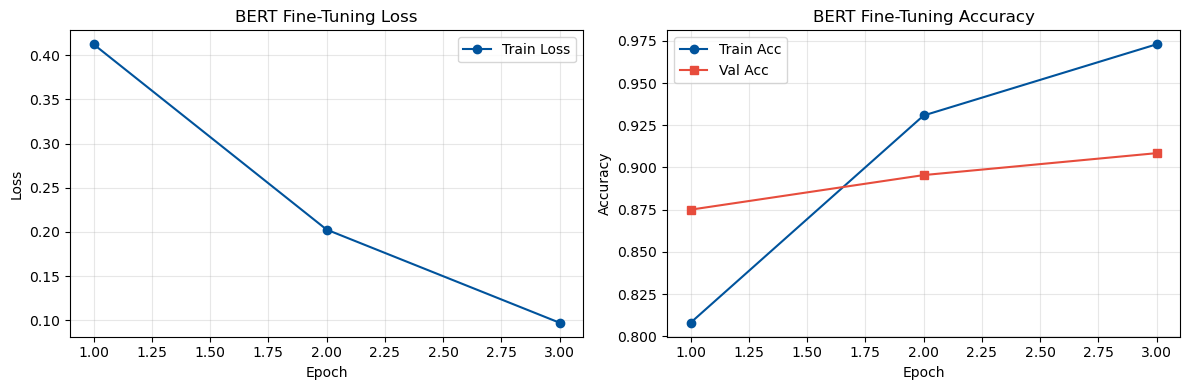


Final BERT Accuracy on test set: 0.9085


In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'o-', color='#00539C', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERT Fine-Tuning Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), train_accs, 'o-', color='#00539C', label='Train Acc')
axes[1].plot(range(1, EPOCHS+1), val_accs, 's-', color='#E74C3C', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERT Fine-Tuning Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal BERT Accuracy on test set: {val_accs[-1]:.4f}")

## 1.6 Test on Custom Sentences

In [11]:
def predict_sentiment_bert(text, model, tokenizer, device):
    """Predict sentiment for a single text using BERT."""
    model.eval()
    encoding = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=MAX_LENGTH, padding='max_length'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    pred = torch.argmax(probs, dim=-1).item()
    label = 'Positive' if pred == 1 else 'Negative'
    confidence = probs[0, pred].item()
    return label, confidence

# Test sentences
test_sentences = [
    "This movie was an absolute masterpiece, the acting was phenomenal.",
    "Terrible film. Waste of time, awful script and bad acting.",
    "The plot was interesting but the pacing felt a bit off.",
    "One of the greatest cinematic experiences I've ever had!",
    "I fell asleep halfway through. Boring and predictable.",
]

print("BERT Sentiment Predictions:\n")
for sent in test_sentences:
    label, conf = predict_sentiment_bert(sent, model, tokenizer, device)
    print(f"  [{label:8s} ({conf:.2%})] {sent}")

BERT Sentiment Predictions:

  [Positive (99.74%)] This movie was an absolute masterpiece, the acting was phenomenal.
  [Negative (99.73%)] Terrible film. Waste of time, awful script and bad acting.
  [Positive (55.43%)] The plot was interesting but the pacing felt a bit off.
  [Positive (99.70%)] One of the greatest cinematic experiences I've ever had!
  [Negative (98.98%)] I fell asleep halfway through. Boring and predictable.


---

# Part 2: T5 for Sequence-to-Sequence Tasks

**T5** (Text-to-Text Transfer Transformer) is an **encoder-decoder** Transformer that treats every NLP task as a text-to-text problem:

| Task | Input | Output |
|------|-------|--------|
| Translation | `"translate English to French: Hello world"` | `"Bonjour le monde"` |
| Summarization | `"summarize: <long text>"` | `"<short summary>"` |
| Sentiment | `"sentiment: I love this movie"` | `"positive"` |

### Architecture

T5 follows the original Transformer architecture from *Attention Is All You Need*:
- **Encoder:** Processes the input text with full bidirectional self-attention
- **Decoder:** Generates output autoregressively with masked self-attention + cross-attention to encoder

$$\text{Cross-Attention:} \quad Q = H_{\text{dec}} W_Q, \quad K = H_{\text{enc}} W_K, \quad V = H_{\text{enc}} W_V$$

We use `t5-small` (60M parameters) for quick experimentation.

## 2.1 T5 for Text Summarization

In [12]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_model_name = 't5-small'
t5_tokenizer = AutoTokenizer.from_pretrained(t5_model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name).to(device)

print(f"T5-small parameters: {sum(p.numel() for p in t5_model.parameters()):,}")
print(f"Vocabulary size: {t5_tokenizer.vocab_size}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5-small parameters: 60,506,624
Vocabulary size: 32100


In [13]:
def t5_generate(model, tokenizer, input_text, max_length=150, device='cpu'):
    """Generate output text from T5 given a prefixed input."""
    inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,           # Beam search for better quality
            early_stopping=True,
            no_repeat_ngram_size=3 # Avoid repetitive n-grams
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# --- Summarization examples ---
article = """The Transformer architecture, introduced by Vaswani et al. in 2017, 
revolutionized natural language processing by replacing recurrent layers with 
self-attention mechanisms. Unlike RNNs which process tokens sequentially, 
Transformers can process all tokens in parallel, leading to significantly faster 
training times. The key innovation is the scaled dot-product attention, which 
computes attention weights between all pairs of tokens simultaneously. This 
allows the model to capture long-range dependencies without the vanishing 
gradient problem that plagues RNNs. BERT, GPT, and T5 are all based on the 
Transformer architecture and have achieved state-of-the-art results on virtually 
every NLP benchmark."""

summary = t5_generate(t5_model, t5_tokenizer, f"summarize: {article}", device=device)
print("=== Summarization ===")
print(f"\nInput ({len(article.split())} words):")
print(article.strip())
print(f"\nSummary ({len(summary.split())} words):")
print(summary)

=== Summarization ===

Input (95 words):
The Transformer architecture, introduced by Vaswani et al. in 2017, 
revolutionized natural language processing by replacing recurrent layers with 
self-attention mechanisms. Unlike RNNs which process tokens sequentially, 
Transformers can process all tokens in parallel, leading to significantly faster 
training times. The key innovation is the scaled dot-product attention, which 
computes attention weights between all pairs of tokens simultaneously. This 
allows the model to capture long-range dependencies without the vanishing 
gradient problem that plagues RNNs. BERT, GPT, and T5 are all based on the 
Transformer architecture and have achieved state-of-the-art results on virtually 
every NLP benchmark.

Summary (39 words):
the Transformer architecture, introduced by Vaswani et al. in 2017, revolutionized natural language processing by replacing recurrent layers with self-attention mechanisms. the key innovation is the scaled dot-product atten

## 2.2 T5 for Translation

In [14]:
# --- Translation examples ---
translation_pairs = [
    "translate English to German: The house is wonderful.",
    "translate English to French: Machine learning is transforming the world.",
    "translate English to Romanian: Attention is all you need.",
]

print("=== Translation ===")
for pair in translation_pairs:
    result = t5_generate(t5_model, t5_tokenizer, pair, max_length=64, device=device)
    print(f"\n  Input:  {pair}")
    print(f"  Output: {result}")

=== Translation ===

  Input:  translate English to German: The house is wonderful.
  Output: Das Haus ist wunderbar.

  Input:  translate English to French: Machine learning is transforming the world.
  Output: L'apprentissage des machines transforme le monde.

  Input:  translate English to Romanian: Attention is all you need.
  Output: Atenţia este tot ceea ce aveţi nevoie.


## 2.3 T5 for Other Tasks

Since T5 treats everything as text-to-text, we can use it for many tasks without changing the architecture:

In [15]:
# --- Sentiment classification ---
sentiment_examples = [
    "sst2 sentence: This movie is fantastic and I loved every moment.",
    "sst2 sentence: The food was terrible and the service was slow.",
    "sst2 sentence: An average experience, nothing special.",
]

print("=== Sentiment (SST2 format) ===")
for ex in sentiment_examples:
    result = t5_generate(t5_model, t5_tokenizer, ex, max_length=10, device=device)
    print(f"  Input:  {ex}")
    print(f"  Output: {result}\n")

# --- Grammar correction (cola) ---
cola_examples = [
    "cola sentence: The boy went to the store.",
    "cola sentence: The boy store to went.",
]

print("=== Grammar Check (CoLA format) ===")
for ex in cola_examples:
    result = t5_generate(t5_model, t5_tokenizer, ex, max_length=10, device=device)
    print(f"  Input:  {ex}")
    print(f"  Output: {result}\n")

=== Sentiment (SST2 format) ===
  Input:  sst2 sentence: This movie is fantastic and I loved every moment.
  Output: positive

  Input:  sst2 sentence: The food was terrible and the service was slow.
  Output: negative

  Input:  sst2 sentence: An average experience, nothing special.
  Output: negative

=== Grammar Check (CoLA format) ===
  Input:  cola sentence: The boy went to the store.
  Output: acceptable

  Input:  cola sentence: The boy store to went.
  Output: acceptable



### Key Takeaway

T5 demonstrates the power of the **text-to-text** paradigm. A single model architecture handles summarization, translation, classification, and more — the task is specified entirely through the input prefix. This is a precursor to modern LLM prompting where the "task" is defined in natural language.

---

# Part 3: Transformer vs. LSTM Comparison

Now we compare BERT (Transformer, encoder-only) against an LSTM baseline on the **same** IMDB sentiment task. This directly illustrates the advantages discussed in the slides:

| Aspect | LSTM | Transformer (BERT) |
|--------|------|--------------------|
| Context | Sequential (left-to-right or bidirectional) | Full bidirectional self-attention |
| Long-range dependencies | Difficult (vanishing gradient) | Native (direct attention) |
| Parallelization | Sequential bottleneck | Fully parallel |
| Pre-training | None (from scratch) | Large-scale pre-training on BookCorpus + Wikipedia |
| Parameters | ~2M (typical) | ~110M (BERT-base) |

## 3.1 LSTM Baseline (Reproduced from Lab 2)

In [16]:
import re
from collections import Counter
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# --- Simple tokenizer (same as Lab 2) ---
def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>',  ' ', text)  # Remove HTML
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# --- Build vocabulary on training data ---
VOCAB_SIZE = 20000
counter = Counter()
raw_train = dataset['train'].select(range(TRAIN_SIZE))
for ex in raw_train:
    counter.update(simple_tokenize(ex['text']))

most_common = counter.most_common(VOCAB_SIZE - 2)  # Reserve 0=<pad>, 1=<unk>
word2idx = {'<pad>': 0, '<unk>': 1}
for i, (word, _) in enumerate(most_common):
    word2idx[word] = i + 2

def encode_text(text):
    tokens = simple_tokenize(text)[:MAX_LENGTH]
    return [word2idx.get(t, 1) for t in tokens]

print(f"LSTM vocabulary size: {len(word2idx)}")

LSTM vocabulary size: 20000


In [17]:
# --- LSTM Dataset and DataLoader ---
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.data = [(encode_text(ex['text']), ex['label']) for ex in hf_dataset]
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = [len(t) for t in texts]
    padded = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=0)
    return padded, torch.tensor(lengths), torch.stack(labels)

raw_test = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))
lstm_train_ds = IMDBDataset(raw_train)
lstm_test_ds  = IMDBDataset(raw_test)

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
lstm_test_loader  = DataLoader(lstm_test_ds,  batch_size=BATCH_SIZE, collate_fn=collate_fn)

print(f"LSTM train samples: {len(lstm_train_ds)}, test samples: {len(lstm_test_ds)}")

LSTM train samples: 5000, test samples: 2000


In [18]:
# --- LSTM Classifier Model (same architecture as Lab 2) ---
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=bidirectional)
        self.dropout = nn.Dropout(dropout)
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in, 1)
    
    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # Concatenate forward and backward final hidden states
        if self.lstm.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        return self.fc(self.dropout(hidden)).squeeze(1)

lstm_model = LSTMClassifier(
    vocab_size=len(word2idx), embed_dim=128, hidden_dim=128, n_layers=2
).to(device)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM parameters: {lstm_params:,}")
print(f"BERT parameters: {total_params:,}")
print(f"Ratio BERT/LSTM: {total_params / lstm_params:.1f}x")

LSTM parameters: 3,219,713
BERT parameters: 109,483,778
Ratio BERT/LSTM: 34.0x


In [19]:
# --- Train the LSTM ---
lstm_criterion = nn.BCEWithLogitsLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_train_accs = []
lstm_val_accs = []

LSTM_EPOCHS = 5

for epoch in range(LSTM_EPOCHS):
    lstm_model.train()
    all_preds, all_labels = [], []
    for texts, lengths, labels in lstm_train_loader:
        texts, labels = texts.to(device), labels.to(device)
        logits = lstm_model(texts, lengths)
        loss = lstm_criterion(logits, labels)
        lstm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        lstm_optimizer.step()
        preds = (torch.sigmoid(logits) > 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    train_acc = accuracy_score(all_labels, all_preds)
    lstm_train_accs.append(train_acc)
    
    # Validation
    lstm_model.eval()
    vp, vl = [], []
    with torch.no_grad():
        for texts, lengths, labels in lstm_test_loader:
            texts = texts.to(device)
            logits = lstm_model(texts, lengths)
            preds = (torch.sigmoid(logits) > 0.5).long()
            vp.extend(preds.cpu().numpy())
            vl.extend(labels.numpy())
    
    v_acc = accuracy_score(vl, vp)
    lstm_val_accs.append(v_acc)
    print(f"LSTM Epoch {epoch+1}/{LSTM_EPOCHS} — Train Acc: {train_acc:.4f}, Val Acc: {v_acc:.4f}")

print(f"\nFinal LSTM Test Accuracy: {lstm_val_accs[-1]:.4f}")

LSTM Epoch 1/5 — Train Acc: 1.0000, Val Acc: 0.5000
LSTM Epoch 2/5 — Train Acc: 1.0000, Val Acc: 0.5000
LSTM Epoch 3/5 — Train Acc: 1.0000, Val Acc: 0.5000
LSTM Epoch 4/5 — Train Acc: 1.0000, Val Acc: 0.5000
LSTM Epoch 5/5 — Train Acc: 1.0000, Val Acc: 0.5000

Final LSTM Test Accuracy: 0.5000


## 3.2 Results Comparison

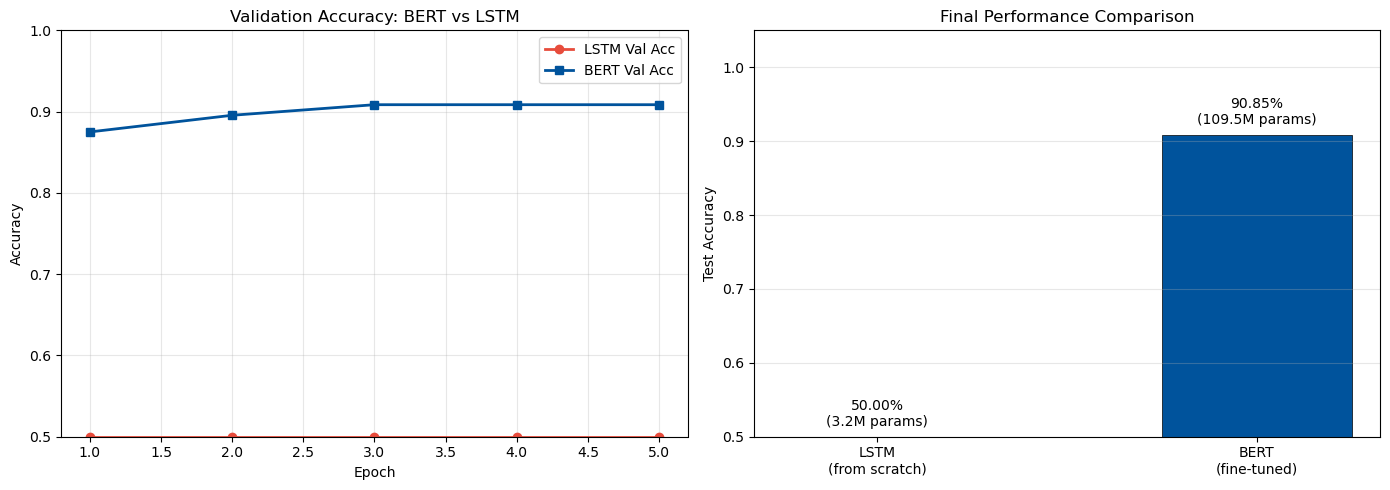


Model                       Accuracy      Parameters
--------------------------------------------------
LSTM (from scratch)           0.5000       3,219,713
BERT (fine-tuned)             0.9085     109,483,778

BERT advantage: +40.8 percentage points


In [20]:
# --- Side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy over epochs
ax = axes[0]
ax.plot(range(1, LSTM_EPOCHS+1), lstm_val_accs, 'o-', color='#E74C3C', label='LSTM Val Acc', linewidth=2)
# For BERT, repeat final value to fill the plot
bert_line = val_accs + [val_accs[-1]] * (LSTM_EPOCHS - len(val_accs))
ax.plot(range(1, LSTM_EPOCHS+1), bert_line[:LSTM_EPOCHS], 's-', color='#00539C', label='BERT Val Acc', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Accuracy: BERT vs LSTM')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Bar chart summary
ax = axes[1]
models_names = ['LSTM\n(from scratch)', 'BERT\n(fine-tuned)']
final_accs = [lstm_val_accs[-1], val_accs[-1]]
param_counts = [lstm_params, total_params]
colors = ['#E74C3C', '#00539C']

bars = ax.bar(models_names, final_accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, acc, params in zip(bars, final_accs, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2%}\n({params/1e6:.1f}M params)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Test Accuracy')
ax.set_title('Final Performance Comparison')
ax.set_ylim([0.5, 1.05])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'Model':<25} {'Accuracy':>10} {'Parameters':>15}")
print(f"{'-'*50}")
print(f"{'LSTM (from scratch)':<25} {lstm_val_accs[-1]:>10.4f} {lstm_params:>15,}")
print(f"{'BERT (fine-tuned)':<25} {val_accs[-1]:>10.4f} {total_params:>15,}")
print(f"\nBERT advantage: +{(val_accs[-1] - lstm_val_accs[-1])*100:.1f} percentage points")

### Interpretation

**Expected results:**
- BERT typically achieves **88-93%** accuracy even with a small subset (5K training examples).
- LSTM from scratch typically reaches **78-85%** with the same data.

**Why BERT wins:**
1. **Pre-training:** BERT has already learned language representations from billions of words. The LSTM starts from random weights.
2. **Full bidirectional context:** BERT's self-attention sees all tokens simultaneously. The bidirectional LSTM processes left-to-right and right-to-left separately, then concatenates.
3. **Long-range dependencies:** Self-attention connects any two tokens in $O(1)$ path length, while LSTM requires $O(n)$ sequential steps.
4. **Subword tokenization (WordPiece):** BERT handles out-of-vocabulary words gracefully through subword splitting, while our LSTM uses simple whitespace tokenization with many `<unk>` tokens.

**Trade-off:** BERT has ~55x more parameters and requires a GPU for practical training. For resource-constrained settings, LSTMs remain viable.

---

# Part 4: Visualizing Attention Weights

One of the key advantages of Transformers is the **interpretability** of attention weights. Each attention head learns different patterns:

$$\alpha_{ij} = \text{softmax}\!\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)$$

where $\alpha_{ij}$ represents how much token $i$ "attends to" token $j$.

Research has shown that different heads capture:
- **Syntactic relations** (subject-verb agreement)
- **Coreference** (pronoun resolution)
- **Positional patterns** (adjacent tokens, sentence boundaries)
- **Semantic similarity** (synonyms, related concepts)

## 4.1 Extract Attention Weights from BERT

In [21]:
def get_attention_weights(text, model, tokenizer, device):
    """
    Extract attention weights from all layers and heads.
    
    Returns:
        attentions: tuple of (n_layers,) tensors, each of shape (1, n_heads, seq_len, seq_len)
        tokens: list of token strings
    """
    model.eval()
    encoding = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True  # Request attention weights
        )
    
    attentions = outputs.attentions  # Tuple of (1, n_heads, seq_len, seq_len)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    
    return attentions, tokens

# Extract attentions for a sample sentence
sample_text = "The movie was not great but the acting was brilliant."
attentions, tokens = get_attention_weights(sample_text, model, tokenizer, device)

print(f"Number of layers: {len(attentions)}")
print(f"Attention shape per layer: {attentions[0].shape}")
print(f"Tokens: {tokens}")

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Number of layers: 12
Attention shape per layer: torch.Size([1, 12, 13, 13])
Tokens: ['[CLS]', 'the', 'movie', 'was', 'not', 'great', 'but', 'the', 'acting', 'was', 'brilliant', '.', '[SEP]']


## 4.2 Visualize Attention Heatmaps

We plot attention matrices for specific layers and heads. Each cell $(i, j)$ shows how much token $i$ attends to token $j$.

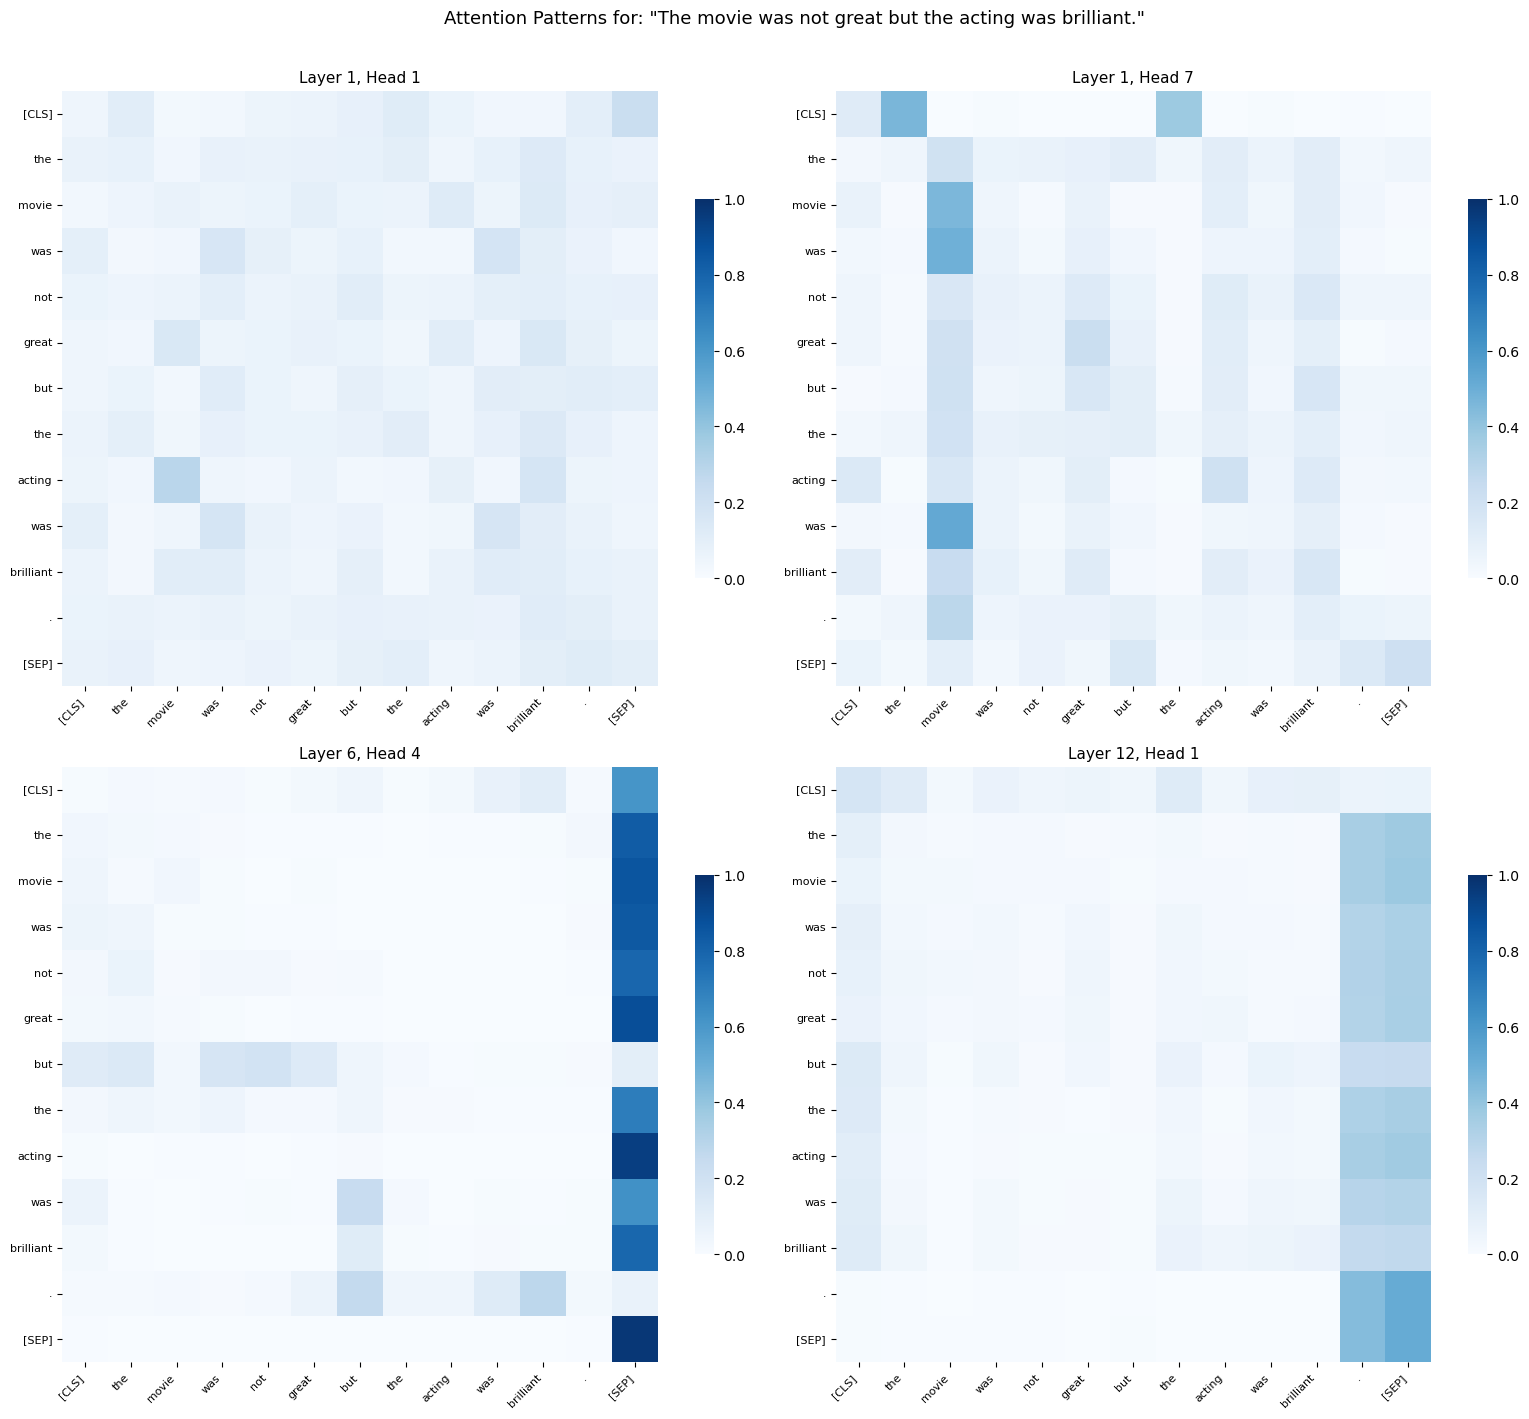

In [22]:
def plot_attention_head(attentions, tokens, layer, head, ax=None):
    """Plot a single attention head's weights as a heatmap."""
    attn = attentions[layer][0, head].cpu().numpy()
    n = len(tokens)
    attn = attn[:n, :n]  # Trim to actual tokens (ignore padding)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
                cmap='Blues', ax=ax, square=True, vmin=0, vmax=1,
                cbar_kws={'shrink': 0.6})
    ax.set_title(f'Layer {layer+1}, Head {head+1}', fontsize=11)
    ax.tick_params(axis='both', labelsize=8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

# Plot 4 different heads from different layers
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
layer_head_pairs = [(0, 0), (0, 6), (5, 3), (11, 0)]  # Various layers/heads

for ax, (l, h) in zip(axes.flat, layer_head_pairs):
    plot_attention_head(attentions, tokens, l, h, ax=ax)

plt.suptitle(f'Attention Patterns for: "{sample_text}"', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4.3 Attention Pattern Analysis

Let's identify common attention patterns across all heads:

In [23]:
def analyze_attention_patterns(attentions, tokens):
    """
    Analyze and classify attention patterns across layers and heads.
    
    Common patterns:
    - Diagonal: tokens attend to themselves
    - Vertical stripe: all tokens attend to one specific token (e.g., [CLS] or [SEP])
    - Off-diagonal: tokens attend to adjacent tokens
    - Broad: tokens attend to many tokens (distributed attention)
    """
    n = len(tokens)
    n_layers = len(attentions)
    n_heads = attentions[0].shape[1]
    
    results = []
    for layer in range(n_layers):
        for head in range(n_heads):
            attn = attentions[layer][0, head, :n, :n].cpu().numpy()
            
            # Diagonal score: average attention on diagonal
            diag_score = np.mean(np.diag(attn))
            
            # Vertical stripe: max column-wise mean
            col_means = np.mean(attn, axis=0)
            vertical_score = np.max(col_means)
            vertical_token = tokens[np.argmax(col_means)]
            
            # Entropy: higher = more distributed attention
            entropy = -np.sum(attn * np.log(attn + 1e-10), axis=-1).mean()
            
            results.append({
                'layer': layer, 'head': head,
                'diag_score': diag_score,
                'vertical_score': vertical_score,
                'vertical_token': vertical_token,
                'entropy': entropy
            })
    
    return results

patterns = analyze_attention_patterns(attentions, tokens)

# Find most interesting patterns
print("=== Attention Pattern Analysis ===")
print(f"\nTotal heads: {len(patterns)} (12 layers x 12 heads)")

# Most diagonal (self-attending)
top_diag = sorted(patterns, key=lambda x: x['diag_score'], reverse=True)[:3]
print(f"\nMost self-attending (diagonal) heads:")
for p in top_diag:
    print(f"  Layer {p['layer']+1}, Head {p['head']+1}: diag_score={p['diag_score']:.3f}")

# Most vertical (attending to specific token)
top_vert = sorted(patterns, key=lambda x: x['vertical_score'], reverse=True)[:3]
print(f"\nMost focused (vertical stripe) heads:")
for p in top_vert:
    print(f"  Layer {p['layer']+1}, Head {p['head']+1}: attends to '{p['vertical_token']}' (score={p['vertical_score']:.3f})")

# Highest entropy (most distributed)
top_entropy = sorted(patterns, key=lambda x: x['entropy'], reverse=True)[:3]
print(f"\nMost distributed (high entropy) heads:")
for p in top_entropy:
    print(f"  Layer {p['layer']+1}, Head {p['head']+1}: entropy={p['entropy']:.3f}")

=== Attention Pattern Analysis ===

Total heads: 144 (12 layers x 12 heads)

Most self-attending (diagonal) heads:
  Layer 11, Head 11: diag_score=0.491
  Layer 3, Head 7: diag_score=0.450
  Layer 12, Head 9: diag_score=0.291

Most focused (vertical stripe) heads:
  Layer 6, Head 2: attends to '[SEP]' (score=0.965)
  Layer 2, Head 7: attends to '[CLS]' (score=0.931)
  Layer 6, Head 7: attends to '[SEP]' (score=0.924)

Most distributed (high entropy) heads:
  Layer 1, Head 1: entropy=2.463
  Layer 1, Head 9: entropy=2.292
  Layer 1, Head 5: entropy=2.265


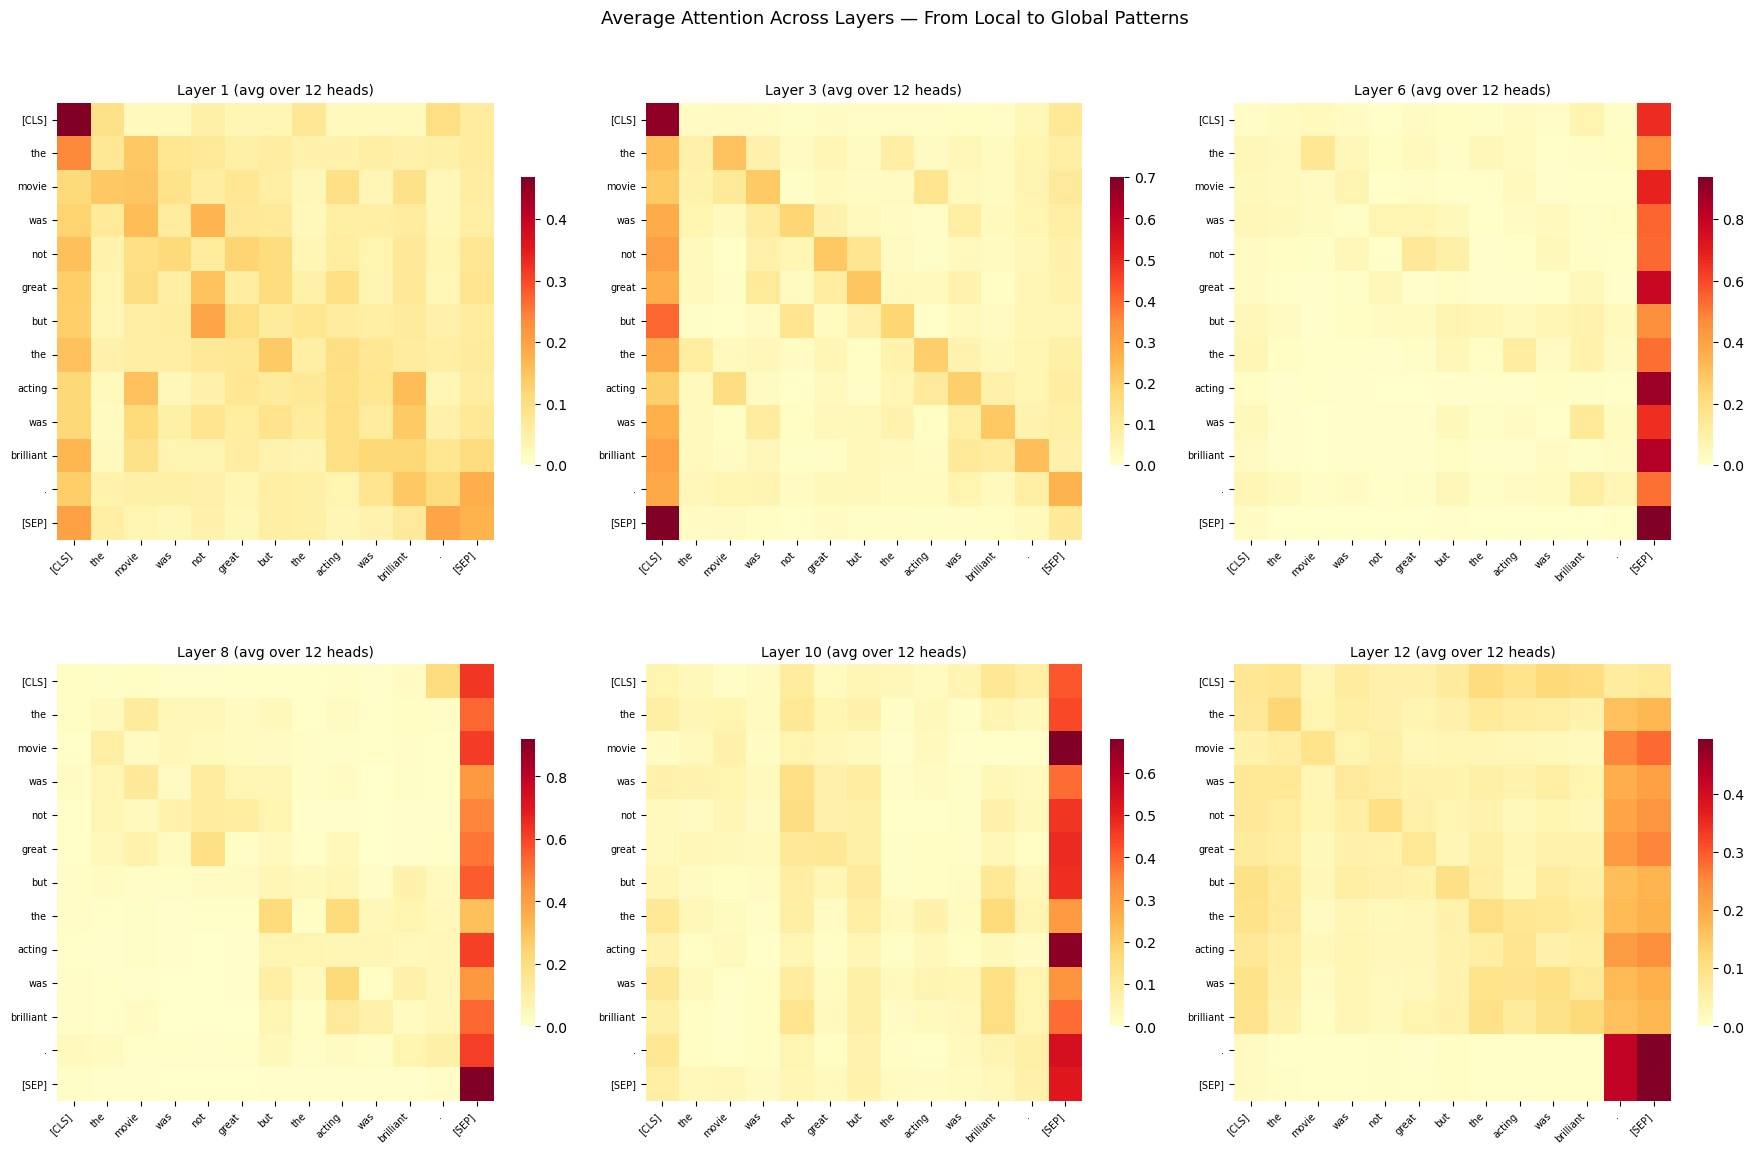

In [24]:
# --- Aggregate attention across layers ---
# Visualize how the average attention pattern evolves from early to late layers

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
layers_to_show = [0, 2, 5, 7, 9, 11]  # Early, middle, and late layers
n = len(tokens)

for ax, layer_idx in zip(axes.flat, layers_to_show):
    # Average across all heads for this layer
    avg_attn = attentions[layer_idx][0, :, :n, :n].mean(dim=0).cpu().numpy()
    sns.heatmap(avg_attn, xticklabels=tokens, yticklabels=tokens,
                cmap='YlOrRd', ax=ax, square=True, vmin=0,
                cbar_kws={'shrink': 0.5})
    ax.set_title(f'Layer {layer_idx+1} (avg over 12 heads)', fontsize=10)
    ax.tick_params(axis='both', labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Average Attention Across Layers — From Local to Global Patterns', fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 Attention to [CLS] Token Across Layers

The `[CLS]` token aggregates information for classification. Let's track how much each token attends to `[CLS]` and vice versa.

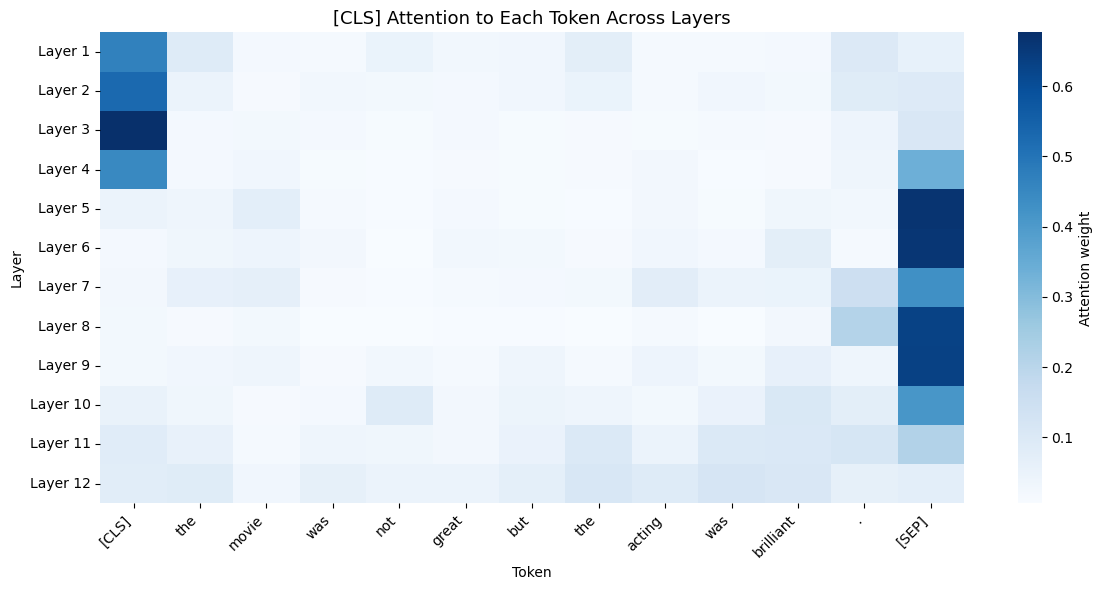


Interpretation:
- Early layers: [CLS] attends broadly (local patterns, positional).
- Later layers: [CLS] focuses on semantically important tokens (e.g., 'not', 'great', 'brilliant').
- This shows how the model gradually builds a sentiment representation.


In [25]:
# How much does each word contribute to [CLS]?
# [CLS] is always token 0 — we look at attn[0, :] (what [CLS] attends to)

n = len(tokens)
cls_attention_per_layer = []

for layer_idx in range(len(attentions)):
    # Average across heads: what [CLS] attends to
    cls_attn = attentions[layer_idx][0, :, 0, :n].mean(dim=0).cpu().numpy()
    cls_attention_per_layer.append(cls_attn)

cls_attn_matrix = np.array(cls_attention_per_layer)  # (n_layers, seq_len)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cls_attn_matrix, xticklabels=tokens, yticklabels=[f'Layer {i+1}' for i in range(12)],
            cmap='Blues', ax=ax, cbar_kws={'label': 'Attention weight'})
ax.set_title('[CLS] Attention to Each Token Across Layers', fontsize=13)
ax.set_xlabel('Token')
ax.set_ylabel('Layer')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Early layers: [CLS] attends broadly (local patterns, positional).")
print("- Later layers: [CLS] focuses on semantically important tokens (e.g., 'not', 'great', 'brilliant').")
print("- This shows how the model gradually builds a sentiment representation.")

## 4.5 Negation Handling: Attention with "not"

A key test for understanding: does BERT properly handle negation? Let's compare attention patterns for a positive and negated sentence.

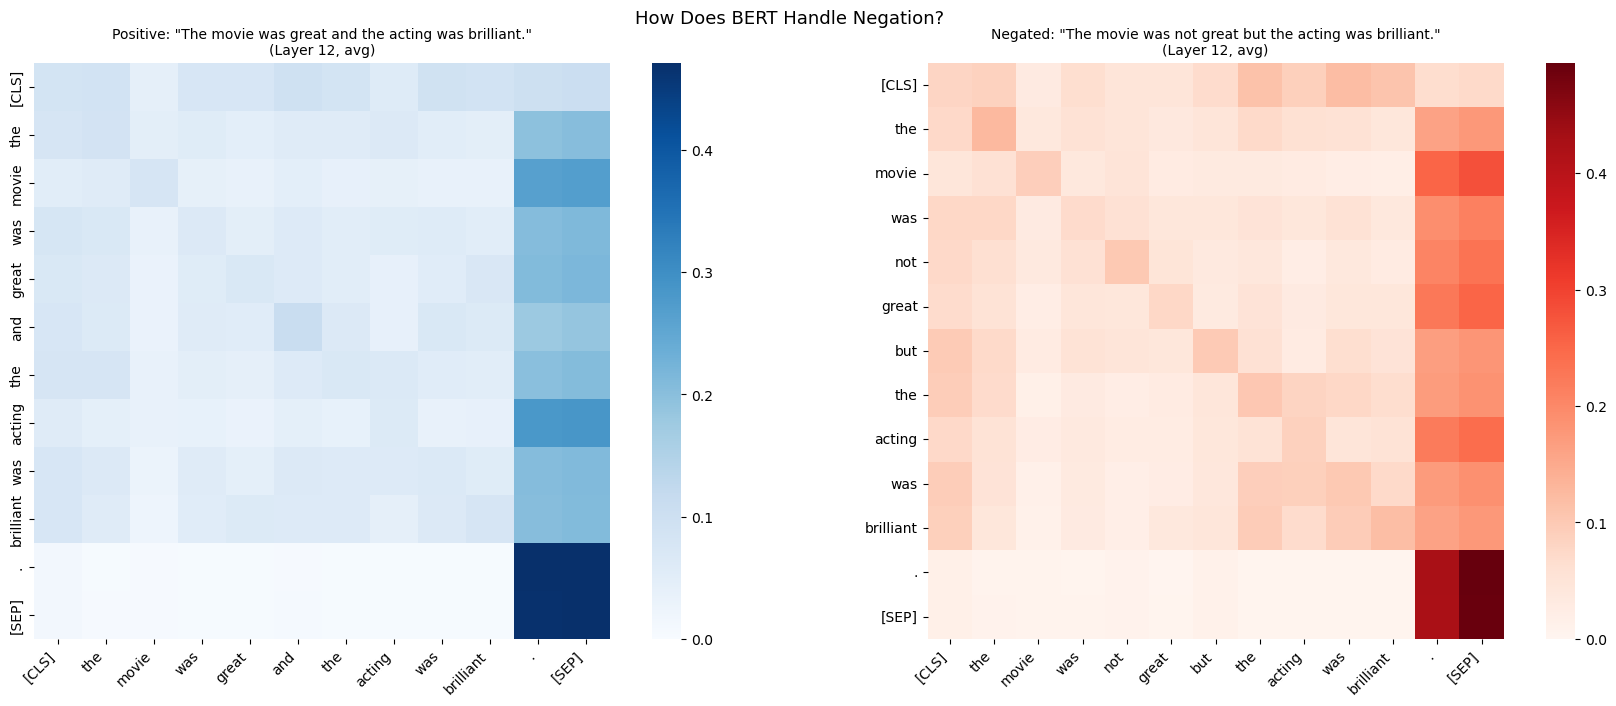

  [Positive (99.66%)] The movie was great and the acting was brilliant.
  [Positive (97.52%)] The movie was not great but the acting was brilliant.


In [26]:
# Compare attention for positive vs negated sentence
positive_text = "The movie was great and the acting was brilliant."
negative_text = "The movie was not great but the acting was brilliant."

attn_pos, tok_pos = get_attention_weights(positive_text, model, tokenizer, device)
attn_neg, tok_neg = get_attention_weights(negative_text, model, tokenizer, device)

# Focus on the last layer (most semantic), average across heads
layer = 11
n_pos = len(tok_pos)
n_neg = len(tok_neg)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

avg_pos = attn_pos[layer][0, :, :n_pos, :n_pos].mean(dim=0).cpu().numpy()
avg_neg = attn_neg[layer][0, :, :n_neg, :n_neg].mean(dim=0).cpu().numpy()

sns.heatmap(avg_pos, xticklabels=tok_pos, yticklabels=tok_pos,
            cmap='Blues', ax=axes[0], square=True, vmin=0)
axes[0].set_title(f'Positive: "{positive_text}"\n(Layer 12, avg)', fontsize=10)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(avg_neg, xticklabels=tok_neg, yticklabels=tok_neg,
            cmap='Reds', ax=axes[1], square=True, vmin=0)
axes[1].set_title(f'Negated: "{negative_text}"\n(Layer 12, avg)', fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('How Does BERT Handle Negation?', fontsize=13)
plt.tight_layout()
plt.show()

# Predict both
for text in [positive_text, negative_text]:
    label, conf = predict_sentiment_bert(text, model, tokenizer, device)
    print(f"  [{label:8s} ({conf:.2%})] {text}")

### Interpretation

- In the negated sentence, we expect to see increased attention between "not" and "great" — the model learns that negation modifies the sentiment of nearby words.
- The bidirectional self-attention allows BERT to capture this interaction natively, whereas a simple left-to-right LSTM must encode "not" in its hidden state and carry it forward.
- This is an example of how the $O(1)$ path length in self-attention helps with compositional semantics.

---

# Part 5: Experimenting with Tokenizers

Tokenization is a critical preprocessing step that directly impacts model performance. Different tokenization strategies produce different vocabulary sizes, sequence lengths, and coverage of rare words.

### Tokenization Methods from the Course

| Method | Algorithm | Used By |
|--------|-----------|--------|
| **Word-level** | Simple whitespace/punctuation split | Traditional NLP |
| **BPE** (Byte Pair Encoding) | Iteratively merge most frequent character pairs | GPT-2, RoBERTa |
| **WordPiece** | Similar to BPE but uses likelihood maximization | BERT |
| **Unigram/SentencePiece** | Probabilistic model, removes least useful tokens | T5, ALBERT, XLNet |

## 5.1 Compare Tokenization Strategies

In [27]:
from transformers import AutoTokenizer

# Load tokenizers from different model families
tokenizers = {
    'BERT (WordPiece)': AutoTokenizer.from_pretrained('bert-base-uncased'),
    'GPT-2 (BPE)':     AutoTokenizer.from_pretrained('gpt2'),
    'T5 (SentencePiece)': AutoTokenizer.from_pretrained('t5-small'),
}

# Test sentences with various challenges
test_texts = [
    "The movie was unbelievable!",
    "Transformers revolutionized natural language processing.",
    "COVID-19 disproportionately affected underprivileged communities.",
    "The tokenizer handles out-of-vocabulary words like 'supercalifragilisticexpialidocious'.",
    "l'intelligence artificielle est extraordinaire",  # French text
]

for text in test_texts:
    print(f"\n{'='*80}")
    print(f"Input: {text}")
    print(f"{'='*80}")
    for name, tok in tokenizers.items():
        tokens = tok.tokenize(text)
        print(f"  {name:25s} [{len(tokens):2d} tokens] {tokens}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Input: The movie was unbelievable!
  BERT (WordPiece)          [ 5 tokens] ['the', 'movie', 'was', 'unbelievable', '!']
  GPT-2 (BPE)               [ 5 tokens] ['The', 'Ġmovie', 'Ġwas', 'Ġunbelievable', '!']
  T5 (SentencePiece)        [ 5 tokens] ['▁The', '▁movie', '▁was', '▁unbelievable', '!']

Input: Transformers revolutionized natural language processing.
  BERT (WordPiece)          [ 7 tokens] ['transformers', 'revolution', '##ized', 'natural', 'language', 'processing', '.']
  GPT-2 (BPE)               [ 8 tokens] ['Transform', 'ers', 'Ġrevolution', 'ized', 'Ġnatural', 'Ġlanguage', 'Ġprocessing', '.']
  T5 (SentencePiece)        [ 8 tokens] ['▁Transformer', 's', '▁revolution', 'ized', '▁natural', '▁language', '▁processing', '.']

Input: COVID-19 disproportionately affected underprivileged communities.
  BERT (WordPiece)          [18 tokens] ['co', '##vid', '-', '19', 'di', '##sp', '##rop', '##ort', '##ion', '##ately', 'affected', 'under', '##pr', '##iv', '##ile', '##ged', 'commun

## 5.2 Vocabulary and Sequence Length Analysis

In [28]:
# Analyze tokenization statistics on a sample of IMDB reviews
sample_texts = [ex['text'] for ex in dataset['train'].select(range(1000))]

print(f"{'Tokenizer':<25} {'Vocab Size':>12} {'Avg Tokens':>12} {'Max Tokens':>12} {'OOV Tokens':>12}")
print(f"{'-'*73}")

stats = {}
for name, tok in tokenizers.items():
    lengths = []
    unk_count = 0
    total_tokens = 0
    unk_id = tok.unk_token_id if tok.unk_token_id is not None else -1
    
    for text in sample_texts:
        token_ids = tok.encode(text, truncation=False)
        lengths.append(len(token_ids))
        total_tokens += len(token_ids)
        if unk_id >= 0:
            unk_count += token_ids.count(unk_id)
    
    avg_len = np.mean(lengths)
    max_len = np.max(lengths)
    unk_rate = unk_count / total_tokens * 100 if total_tokens > 0 else 0
    
    stats[name] = {'avg': avg_len, 'max': max_len, 'unk_rate': unk_rate, 'lengths': lengths}
    print(f"{name:<25} {tok.vocab_size:>12,} {avg_len:>12.1f} {max_len:>12d} {unk_rate:>11.2f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


Tokenizer                   Vocab Size   Avg Tokens   Max Tokens   OOV Tokens
-------------------------------------------------------------------------


Token indices sequence length is longer than the specified maximum sequence length for this model (1168 > 1024). Running this sequence through the model will result in indexing errors


BERT (WordPiece)                30,522        315.1         1525        0.00%


Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


GPT-2 (BPE)                     50,257        298.9         1426        0.00%
T5 (SentencePiece)              32,100        354.4         1724        1.32%


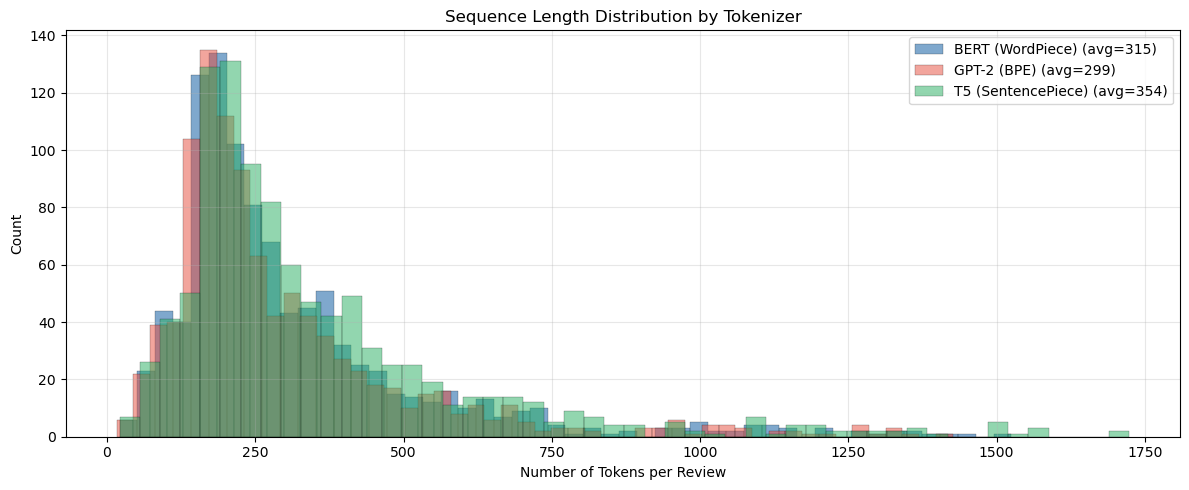


Key observations:
- BPE (GPT-2) tends to produce slightly longer sequences than WordPiece (BERT).
- SentencePiece (T5) uses a unigram model and produces competitive lengths.
- Longer sequences mean more computation in self-attention (O(n^2) complexity).
- Subword tokenizers virtually eliminate OOV tokens, unlike word-level approaches.


In [29]:
# Plot sequence length distributions
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#00539C', '#E74C3C', '#27AE60']
for (name, s), color in zip(stats.items(), colors):
    ax.hist(s['lengths'], bins=50, alpha=0.5, label=f"{name} (avg={s['avg']:.0f})",
            color=color, edgecolor='black', linewidth=0.3)

ax.set_xlabel('Number of Tokens per Review')
ax.set_ylabel('Count')
ax.set_title('Sequence Length Distribution by Tokenizer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- BPE (GPT-2) tends to produce slightly longer sequences than WordPiece (BERT).")
print("- SentencePiece (T5) uses a unigram model and produces competitive lengths.")
print("- Longer sequences mean more computation in self-attention (O(n^2) complexity).")
print("- Subword tokenizers virtually eliminate OOV tokens, unlike word-level approaches.")

## 5.3 Impact of Tokenizer on Downstream Performance

We compare the word-level tokenizer (from our LSTM) against BERT's WordPiece on a **token overlap** analysis — how many unique tokens does each approach need?

In [30]:
# Compare word-level vs subword tokenization
word_level_counter = Counter()
bert_subword_counter = Counter()
bert_tok = tokenizers['BERT (WordPiece)']

for text in sample_texts[:500]:
    word_level_counter.update(simple_tokenize(text))
    bert_subword_counter.update(bert_tok.tokenize(text))

print(f"{'Metric':<35} {'Word-level':>12} {'WordPiece':>12}")
print(f"{'-'*59}")
print(f"{'Unique tokens seen':<35} {len(word_level_counter):>12,} {len(bert_subword_counter):>12,}")
print(f"{'Tokens appearing once (hapax)':<35} {sum(1 for v in word_level_counter.values() if v==1):>12,} {sum(1 for v in bert_subword_counter.values() if v==1):>12,}")
print(f"{'Coverage of top 5000 tokens':<35} {sum(v for _,v in word_level_counter.most_common(5000))/sum(word_level_counter.values()):>12.1%} {sum(v for _,v in bert_subword_counter.most_common(5000))/sum(bert_subword_counter.values()):>12.1%}")

print("\nKey insight:")
print("  Word-level tokenization creates many rare tokens (hapax legomena) that the")
print("  model rarely sees during training. Subword tokenization breaks these into")
print("  familiar pieces, enabling better generalization to unseen words.")

Metric                                Word-level    WordPiece
-----------------------------------------------------------
Unique tokens seen                        11,556       10,040
Tokens appearing once (hapax)              6,112        3,767
Coverage of top 5000 tokens                93.5%        95.8%

Key insight:
  Word-level tokenization creates many rare tokens (hapax legomena) that the
  model rarely sees during training. Subword tokenization breaks these into
  familiar pieces, enabling better generalization to unseen words.


In [31]:
# Visualize: how subword tokenization handles rare/complex words
complex_words = [
    "unbelievable",
    "disproportionately",
    "cinematography",
    "underrepresented",
    "breathtakingly",
    "disappointingly",
    "COVID-19",
    "state-of-the-art",
]

print(f"{'Word':<25} {'BERT (WordPiece)':<35} {'GPT-2 (BPE)':<35} {'T5 (SentencePiece)'}")
print(f"{'-'*110}")
for word in complex_words:
    bert_tokens  = tokenizers['BERT (WordPiece)'].tokenize(word)
    gpt2_tokens  = tokenizers['GPT-2 (BPE)'].tokenize(word)
    t5_tokens    = tokenizers['T5 (SentencePiece)'].tokenize(word)
    print(f"{word:<25} {str(bert_tokens):<35} {str(gpt2_tokens):<35} {str(t5_tokens)}")

Word                      BERT (WordPiece)                    GPT-2 (BPE)                         T5 (SentencePiece)
--------------------------------------------------------------------------------------------------------------
unbelievable              ['unbelievable']                    ['un', 'bel', 'iev', 'able']        ['▁unbelievable']
disproportionately        ['di', '##sp', '##rop', '##ort', '##ion', '##ately'] ['dis', 'pro', 'portion', 'ately']  ['▁', 'disproportionate', 'ly']
cinematography            ['cinematography']                  ['c', 'inem', 'atography']          ['▁cinema', 't', 'ography']
underrepresented          ['under', '##re', '##pres', '##ented'] ['under', 'represented']            ['▁under', 'represented']
breathtakingly            ['breath', '##taking', '##ly']      ['b', 'reat', 'htaking', 'ly']      ['▁breathtaking', 'ly']
disappointingly           ['disappointing', '##ly']           ['dis', 'app', 'oint', 'ingly']     ['▁disappointing', 'ly']
COVID-19   

## 5.4 Training a Custom BPE Tokenizer

Using the `tokenizers` library (Hugging Face), we can train our own BPE tokenizer from scratch on the IMDB corpus to see how vocabulary size affects tokenization.

In [32]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

def train_bpe_tokenizer(texts, vocab_size):
    """Train a BPE tokenizer on the given texts."""
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"]
    )
    tok.train_from_iterator(texts, trainer)
    return tok

# Train BPE tokenizers with different vocabulary sizes
vocab_sizes = [1000, 5000, 10000, 30000]
bpe_tokenizers = {}

for vs in vocab_sizes:
    bpe_tokenizers[vs] = train_bpe_tokenizer(sample_texts, vs)
    print(f"Trained BPE tokenizer with vocab_size={vs}")

# Compare tokenization of a sample review
sample = "The cinematography was breathtakingly beautiful but the plot was disappointingly predictable."
print(f"\nInput: {sample}\n")

for vs, tok in bpe_tokenizers.items():
    encoded = tok.encode(sample)
    print(f"  vocab={vs:>6,}: [{len(encoded.tokens):2d} tokens] {encoded.tokens}")




Trained BPE tokenizer with vocab_size=1000



Trained BPE tokenizer with vocab_size=5000



Trained BPE tokenizer with vocab_size=10000



Trained BPE tokenizer with vocab_size=30000

Input: The cinematography was breathtakingly beautiful but the plot was disappointingly predictable.

  vocab= 1,000: [29 tokens] ['The', 'c', 'in', 'em', 'at', 'o', 'grap', 'hy', 'was', 'bre', 'ath', 'ta', 'king', 'ly', 'be', 'a', 'ut', 'if', 'ul', 'but', 'the', 'plot', 'was', 'disappoint', 'ing', 'ly', 'predict', 'able', '.']
  vocab= 5,000: [15 tokens] ['The', 'cinematography', 'was', 'breath', 'taking', 'ly', 'beautiful', 'but', 'the', 'plot', 'was', 'disappoint', 'ingly', 'predictable', '.']
  vocab=10,000: [14 tokens] ['The', 'cinematography', 'was', 'breathtaking', 'ly', 'beautiful', 'but', 'the', 'plot', 'was', 'disappoint', 'ingly', 'predictable', '.']
  vocab=30,000: [12 tokens] ['The', 'cinematography', 'was', 'breathtakingly', 'beautiful', 'but', 'the', 'plot', 'was', 'disappointingly', 'pr

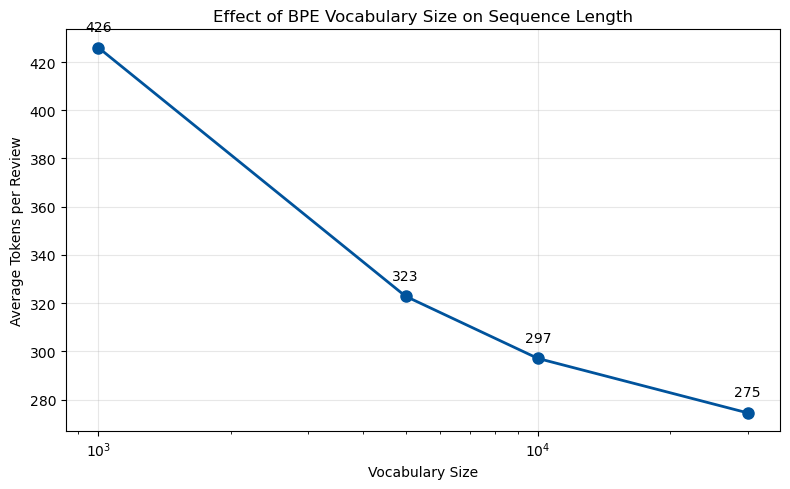


Key insight:
  Larger vocabularies → shorter sequences (fewer subword splits needed).
  Shorter sequences → faster self-attention (O(n^2) complexity).
  But larger vocabularies → larger embedding matrices → more parameters.
  The sweet spot depends on the data and compute budget.


In [33]:
# Plot: vocabulary size vs average sequence length
avg_lengths = []
for vs, tok in bpe_tokenizers.items():
    lens = [len(tok.encode(t).tokens) for t in sample_texts[:200]]
    avg_lengths.append(np.mean(lens))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(vocab_sizes, avg_lengths, 'o-', color='#00539C', linewidth=2, markersize=8)
ax.set_xlabel('Vocabulary Size')
ax.set_ylabel('Average Tokens per Review')
ax.set_title('Effect of BPE Vocabulary Size on Sequence Length')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

for vs, al in zip(vocab_sizes, avg_lengths):
    ax.annotate(f'{al:.0f}', (vs, al), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey insight:")
print("  Larger vocabularies → shorter sequences (fewer subword splits needed).")
print("  Shorter sequences → faster self-attention (O(n^2) complexity).")
print("  But larger vocabularies → larger embedding matrices → more parameters.")
print("  The sweet spot depends on the data and compute budget.")

---

# Summary

## What We Learned

| Task | Key Concept | Result |
|------|------------|--------|
| **BERT fine-tuning** | Pre-training + small LR + few epochs | ~90% accuracy with only 5K examples |
| **T5 seq2seq** | Text-to-text paradigm, encoder-decoder | Summarization, translation, classification |
| **BERT vs LSTM** | Pre-training, self-attention, subword tokens | BERT significantly outperforms LSTM |
| **Attention visualization** | Interpretable attention patterns | Different heads learn syntax, semantics, position |
| **Tokenizer comparison** | BPE, WordPiece, SentencePiece | Subword methods eliminate OOV, control seq length |

## Key Formulas Recap

- **Self-attention:** $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$
- **Multi-head:** $\text{MultiHead} = \text{Concat}(h_1, \ldots, h_H)W^O$
- **BERT classification:** $\hat{y} = \text{softmax}(W \cdot h_{[\text{CLS}]} + b)$
- **T5 cross-attention:** $Q = H_{\text{dec}}W_Q, \; K = H_{\text{enc}}W_K, \; V = H_{\text{enc}}W_V$

## Exercises

1. **Experiment with learning rate:** Try $1 \times 10^{-5}$, $5 \times 10^{-5}$, and $1 \times 10^{-4}$ for BERT fine-tuning. Plot the validation accuracy curves. What happens with too large a learning rate?

2. **Layer freezing:** Freeze BERT's first 6 layers and only fine-tune the last 6. Compare accuracy and training speed. When would this strategy be beneficial?

3. **DistilBERT:** Replace `bert-base-uncased` with `distilbert-base-uncased` (6 layers instead of 12, ~66M parameters). Compare accuracy, inference speed, and attention patterns.

4. **T5 fine-tuning:** Fine-tune T5-small on a specific task (e.g., IMDB sentiment as text-to-text: input = `"classify: <review>"`, output = `"positive"` / `"negative"`). Compare with the pre-trained zero-shot performance.

5. **Attention head pruning:** For each layer, identify the head with the lowest average entropy (most "degenerate"). What happens to model accuracy if you zero out those heads? This relates to efficient Transformer research.